# Vergleich der Modelle 

- Logistic Regression
- SVM
- Ranfom Forest
- Gradient Boosting

Ziel für BA: Ermittlung des besten Klassifikationsmodells

## Imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from scripts.myml import loso_binary_nested_cv
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

## Daten Laden

In [ ]:
DATASET_PATH = Path("dataset/np-dataset")
X = np.load(DATASET_PATH / "X.npy")
X_catch22 = np.load(DATASET_PATH / "X_catch22.npy")
X_catch22_feature_names = np.load(DATASET_PATH / "feature_names.npy")
y_heater = np.load(DATASET_PATH / "y_heater.npy")
subjects = np.load(DATASET_PATH / "subjects.npy")
y = np.argmax(y_heater, axis=1)

# EMG sensor bei 42 war defekt
valid = subjects != 42
X_catch22 = X_catch22[valid]
y = y[valid]
subjects = subjects[valid]

In [10]:
print(f"X shape : {X_catch22.shape}")
print(f"y shape : {y.shape}   classes: {np.unique(y).tolist()}")
print(f"subjects : {np.unique(subjects).shape[0]} unique subjects")
print(f"Class counts : { {c: int((y==c).sum()) for c in range(6)} }")

X shape : (2447, 174)
y shape : (2447,)   classes: [0, 1, 2, 3, 4, 5]
subjects : 51 unique subjects
Class counts : {0: 408, 1: 408, 2: 408, 3: 407, 4: 408, 5: 408}


## Hyperparameter Gids

In [11]:
PARAM_GRID_LOGREG = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [5000],
}

PARAM_GRID_SVM = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1],
}

PARAM_GRID = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

PARAM_GRID_XGB = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
}

INNER_N_SPLITS = 5
RANDOM_STATE = 42

## Define and Setup Comparison

In [12]:
class_comparison = (0, 5)
mask = (y==class_comparison[0]) | (y==class_comparison[1])
X_filtered = X_catch22[mask]
y_filtered = y[mask]
group_labels = subjects[mask]
y_binary = (y_filtered == class_comparison[1]).astype(int)

## Train Models

In [13]:
# Logistic Regression
logreg = LogisticRegression(random_state=RANDOM_STATE)
logreg_results = loso_binary_nested_cv(
    X_filtered,
    y_binary,
    group_labels,
    logreg,
    PARAM_GRID_LOGREG,
    model_type="classifier"
)

print(f"    Accuracy : {logreg_results['accuracy']:.3f} ± {logreg_results['accuracy_std']:.3f}")
print(f"    F1       : {logreg_results['f1']:.3f} ± {logreg_results['f1_std']:.3f}")
print(f"    AUC      : {logreg_results['auc']:.3f} ± {logreg_results['auc_std']:.3f}")

/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/pytho

    Accuracy : 0.881 ± 0.103
    F1       : 0.874 ± 0.123
    AUC      : 0.967 ± 0.063


/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/pytho

In [14]:
# SVM
svm = SVC(random_state=RANDOM_STATE, probability=True)
svm_results = loso_binary_nested_cv(
    X_filtered,
    y_binary,
    group_labels,
    svm,
    PARAM_GRID_SVM,
    model_type="classifier"
)
print(f"    Accuracy : {svm_results['accuracy']:.3f} ± {svm_results['accuracy_std']:.3f}")
print(f"    F1       : {svm_results['f1']:.3f} ± {svm_results['f1_std']:.3f}")
print(f"    AUC      : {svm_results['auc']:.3f} ± {svm_results['auc_std']:.3f}")

    Accuracy : 0.883 ± 0.093
    F1       : 0.877 ± 0.108
    AUC      : 0.958 ± 0.071


In [15]:
# Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_results = loso_binary_nested_cv(
    X_filtered,
    y_binary,
    group_labels,
    rf,
    PARAM_GRID,
    model_type="classifier"
)
print(f"    Accuracy : {rf_results['accuracy']:.3f} ± {rf_results['accuracy_std']:.3f}")
print(f"    F1       : {rf_results['f1']:.3f} ± {rf_results['f1_std']:.3f}")
print(f"    AUC      : {rf_results['auc']:.3f} ± {rf_results['auc_std']:.3f}")

    Accuracy : 0.917 ± 0.081
    F1       : 0.913 ± 0.090
    AUC      : 0.976 ± 0.048


In [16]:
# Gradient Boosting
xgb = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')
xgb_results = loso_binary_nested_cv(
    X_filtered,
    y_binary,
    group_labels,
    xgb,
    PARAM_GRID_XGB,
    model_type="classifier"
)
print(f"    Accuracy : {xgb_results['accuracy']:.3f} ± {xgb_results['accuracy_std']:.3f}")
print(f"    F1       : {xgb_results['f1']:.3f} ± {xgb_results['f1_std']:.3f}")
print(f"    AUC      : {xgb_results['auc']:.3f} ± {xgb_results['auc_std']:.3f}")    

/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:28:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:28:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recognition_ba/painenv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:28:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/wielandcremer/Documents/Uni/6. Semester/pain_recogniti

    Accuracy : 0.892 ± 0.107
    F1       : 0.888 ± 0.122
    AUC      : 0.965 ± 0.069


## Auswertung + ROC & Confusion Matrix

In [ ]:
model_results = {
    'Logistic Regression': logreg_results,
    'SVM': svm_results,
    'Random Forest': rf_results,
    'XGBoost': xgb_results,
}
class_labels = [f't{class_comparison[0]}', f't{class_comparison[1]}']

### Vergleichstabelle

In [ ]:
rows = []

for name, res in model_results.items():
    row = {
        "Model": name,
        "Accuracy": f"{res['accuracy']:.3f} ± {res['accuracy_std']:.3f}",
        "F1": f"{res['f1']:.3f} ± {res['f1_std']:.3f}",
        "AUC": f"{res['auc']:.3f} ± {res['auc_std']:.3f}",
    }
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("Model")

comparison_df

NameError: name 'model_results' is not defined

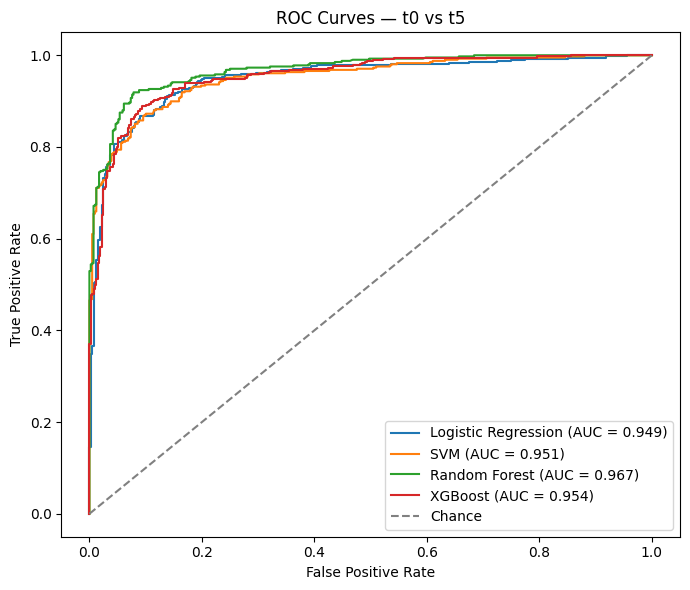

In [19]:
# ROC Curves (alle Modelle in einem Plot)
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in model_results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_score'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], '--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — t{class_comparison[0]} vs t{class_comparison[1]}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

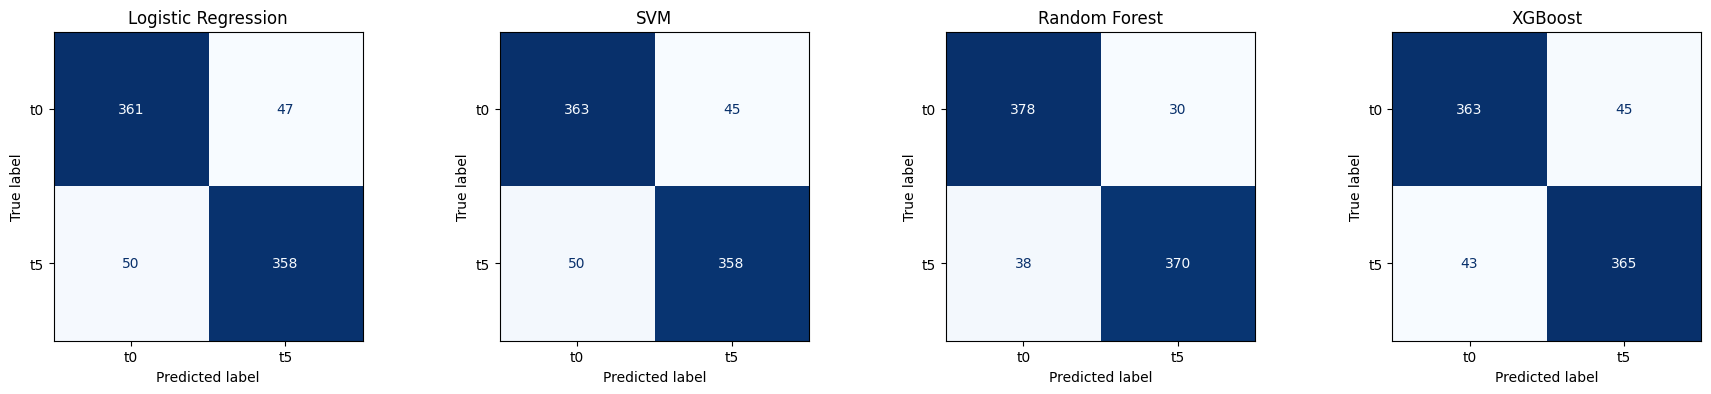

In [20]:
# Confusion Matrices (eine pro Modell)
fig, axes = plt.subplots(1, len(model_results), figsize=(4.5 * len(model_results), 4))
for ax, (name, res) in zip(axes, model_results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()